# ============================================================
# 🚗 CAR PRICE PREDICTION PROJECT
# Internship Task 9 Submission
# Submitted By : Mayur Bavaskar
# ============================================================

## 📌 Problem Statement
The objective of this project is to build a complete end-to-end data science solution to predict car prices based on various features such as year, fuel type, kilometers driven, engine, and more.

## 🎯 Objectives
- Perform data cleaning & preprocessing
- Conduct EDA for insights
- Build ML model
- Evaluate performance
- Deploy using Streamlit

## 1. IMPORTING REQUIRED LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

import pickle
import warnings
warnings.filterwarnings('ignore')

## 2. LOADING THE DATASET

In [3]:
df = pd.read_excel('Data_Train.xlsx')
df.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [4]:
print('Shape of Dataset:', df.shape)

Shape of Dataset: (6019, 13)


## STEP 3 : DATA EXPLORATION

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               6019 non-null   object 
 1   Location           6019 non-null   object 
 2   Year               6019 non-null   int64  
 3   Kilometers_Driven  6019 non-null   int64  
 4   Fuel_Type          6019 non-null   object 
 5   Transmission       6019 non-null   object 
 6   Owner_Type         6019 non-null   object 
 7   Mileage            6017 non-null   object 
 8   Engine             5983 non-null   object 
 9   Power              5983 non-null   object 
 10  Seats              5977 non-null   float64
 11  New_Price          824 non-null    object 
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(2), object(9)
memory usage: 611.4+ KB


In [6]:
df.describe()

,Year,Kilometers_Driven,Seats,Price
count,6019.000000,6.019000e+03,5977.000000,6019.000000
mean,2013.358199,5.873838e+04,5.278735,9.479468
std,3.269742,9.126884e+04,0.808840,11.187917
min,1998.000000,1.710000e+02,0.000000,0.440000
25%,2011.000000,3.400000e+04,5.000000,3.500000
50%,2014.000000,5.300000e+04,5.000000,5.640000
75%,2016.000000,7.300000e+04,5.000000,9.950000
max,2019.000000,6.500000e+06,10.000000,160.000000


In [7]:
# Checking Missing Values
print('Missing Values in Each Column:')
print(df.isnull().sum())

Missing Values in Each Column:
Name                    0
Location                0
Year                    0
Kilometers_Driven       0
Fuel_Type               0
Transmission            0
Owner_Type              0
Mileage                 2
Engine                 36
Power                  36
Seats                  42
New_Price            5195
Price                   0
dtype: int64


## STEP 4 : DATA CLEANING & PREPROCESSING

In [8]:
# Extracting numeric values from Mileage, Engine, Power columns

df['Mileage'] = df['Mileage'].str.extract('(\d+\.?\d*)').astype(float)
df['Engine'] = df['Engine'].str.extract('(\d+\.?\d*)').astype(float)
df['Power'] = df['Power'].str.extract('(\d+\.?\d*)').astype(float)

In [9]:
# Extracting numeric value from New_Price
df['New_Price'] = df['New_Price'].str.extract('(\d+\.?\d*)').astype(float)

In [10]:
# Dropping rows where target (Price) is null
df.dropna(subset=['Price'], inplace=True)

# Filling missing values with median for numeric columns
for col in ['Mileage', 'Engine', 'Power', 'Seats', 'New_Price']:
    df[col].fillna(df[col].median(), inplace=True)

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
New_Price            0
Price                0
dtype: int64


In [11]:
# Dropping Name column (too many unique values, not useful directly)
df.drop(columns=['Name'], inplace=True)

# Creating Car Age feature from Year
df['Car_Age'] = 2024 - df['Year']
df.drop(columns=['Year'], inplace=True)

df.head()

,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age
0,Mumbai,72000,CNG,Manual,First,26.60,998.0,58.16,5.0,11.415,1.75,14
1,Pune,41000,Diesel,Manual,First,19.67,1582.0,126.20,5.0,11.415,12.50,9
2,Chennai,46000,Petrol,Manual,First,18.20,1199.0,88.70,5.0,8.610,4.50,13
3,Chennai,87000,Diesel,Manual,First,20.77,1248.0,88.76,7.0,11.415,6.00,12
4,Coimbatore,40670,Diesel,Automatic,Second,15.20,1968.0,140.80,5.0,11.415,17.74,11


In [12]:
# Label Encoding categorical columns

le = LabelEncoder()
cat_cols = ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('Encoding Done!')
df.head()

Encoding Done!


,Location,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price,Car_Age
0,9,72000,0,1,0,26.60,998.0,58.16,5.0,11.415,1.75,14
1,10,41000,1,1,0,19.67,1582.0,126.20,5.0,11.415,12.50,9
2,2,46000,4,1,0,18.20,1199.0,88.70,5.0,8.610,4.50,13
3,2,87000,1,1,0,20.77,1248.0,88.76,7.0,11.415,6.00,12
4,3,40670,1,0,2,15.20,1968.0,140.80,5.0,11.415,17.74,11


## STEP 5 : EXPLORATORY DATA ANALYSIS (EDA)

### 1. Distribution of Car Prices

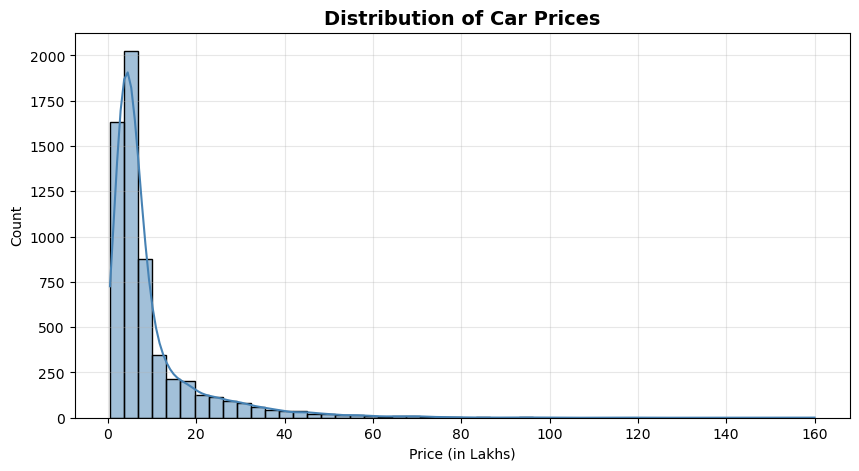

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Price'],
             bins=50,
             kde=True,
             color='steelblue')

plt.title('Distribution of Car Prices',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Price (in Lakhs)')
plt.ylabel('Count')
plt.grid(alpha=0.3)
plt.show()

### 2. Fuel Type vs Price

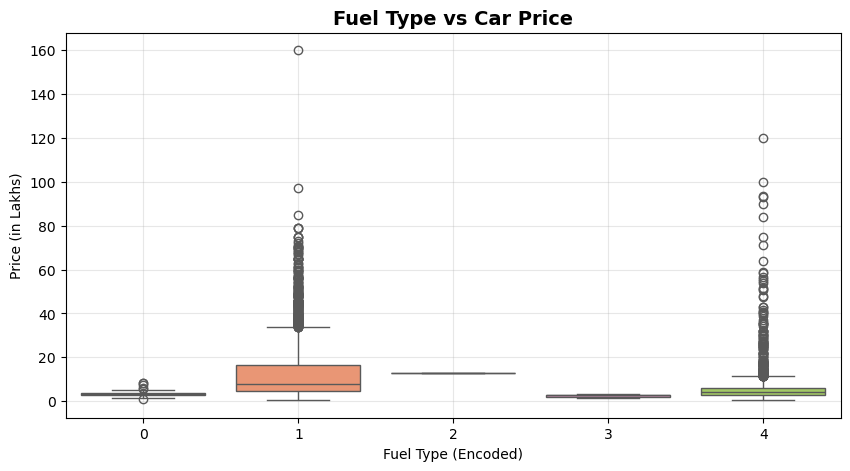

In [14]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df,
            x='Fuel_Type',
            y='Price',
            palette='Set2')

plt.title('Fuel Type vs Car Price',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Fuel Type (Encoded)')
plt.ylabel('Price (in Lakhs)')
plt.grid(alpha=0.3)
plt.show()

### 3. Transmission vs Price

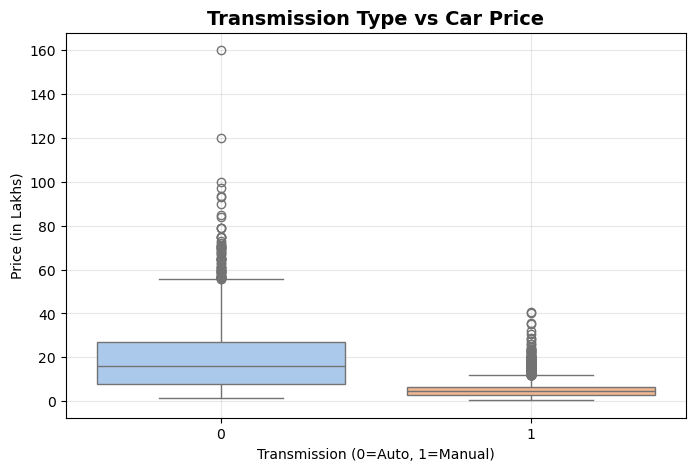

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df,
            x='Transmission',
            y='Price',
            palette='pastel')

plt.title('Transmission Type vs Car Price',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Transmission (0=Auto, 1=Manual)')
plt.ylabel('Price (in Lakhs)')
plt.grid(alpha=0.3)
plt.show()

### 4. Car Age vs Price

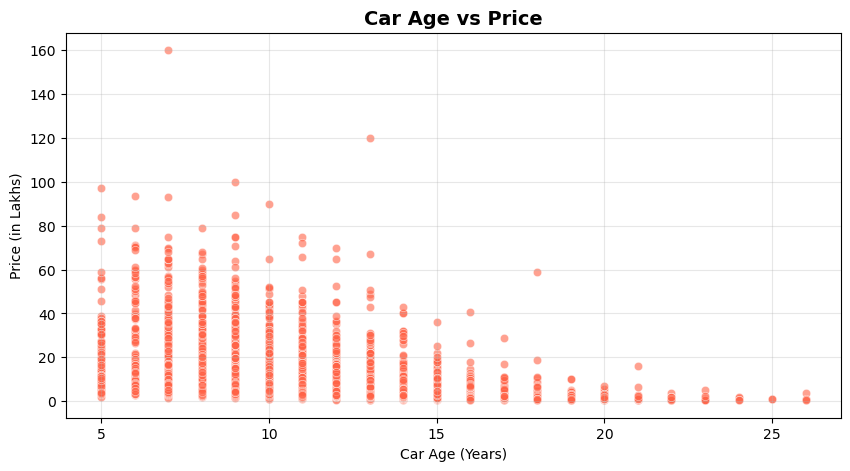

In [16]:
plt.figure(figsize=(10, 5))

sns.scatterplot(data=df,
                x='Car_Age',
                y='Price',
                color='tomato',
                alpha=0.6)

plt.title('Car Age vs Price',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Car Age (Years)')
plt.ylabel('Price (in Lakhs)')
plt.grid(alpha=0.3)
plt.show()

### 5. Kilometers Driven vs Price

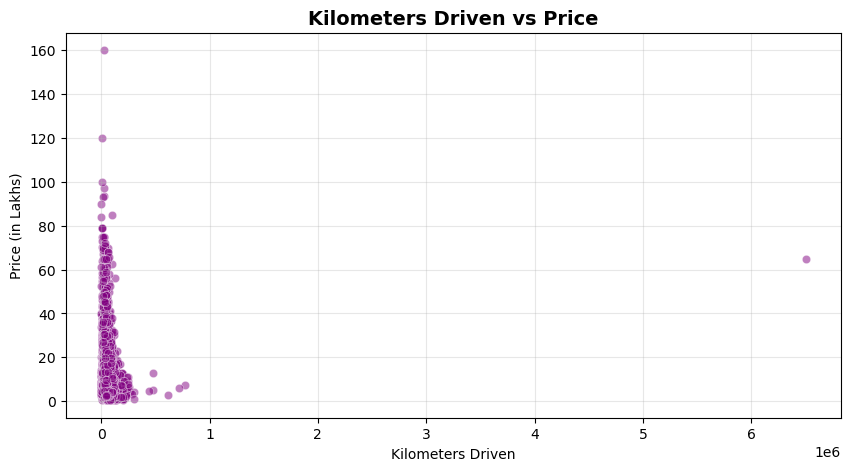

In [17]:
plt.figure(figsize=(10, 5))

sns.scatterplot(data=df,
                x='Kilometers_Driven',
                y='Price',
                color='purple',
                alpha=0.5)

plt.title('Kilometers Driven vs Price',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Kilometers Driven')
plt.ylabel('Price (in Lakhs)')
plt.grid(alpha=0.3)
plt.show()

### 6. Correlation Heatmap

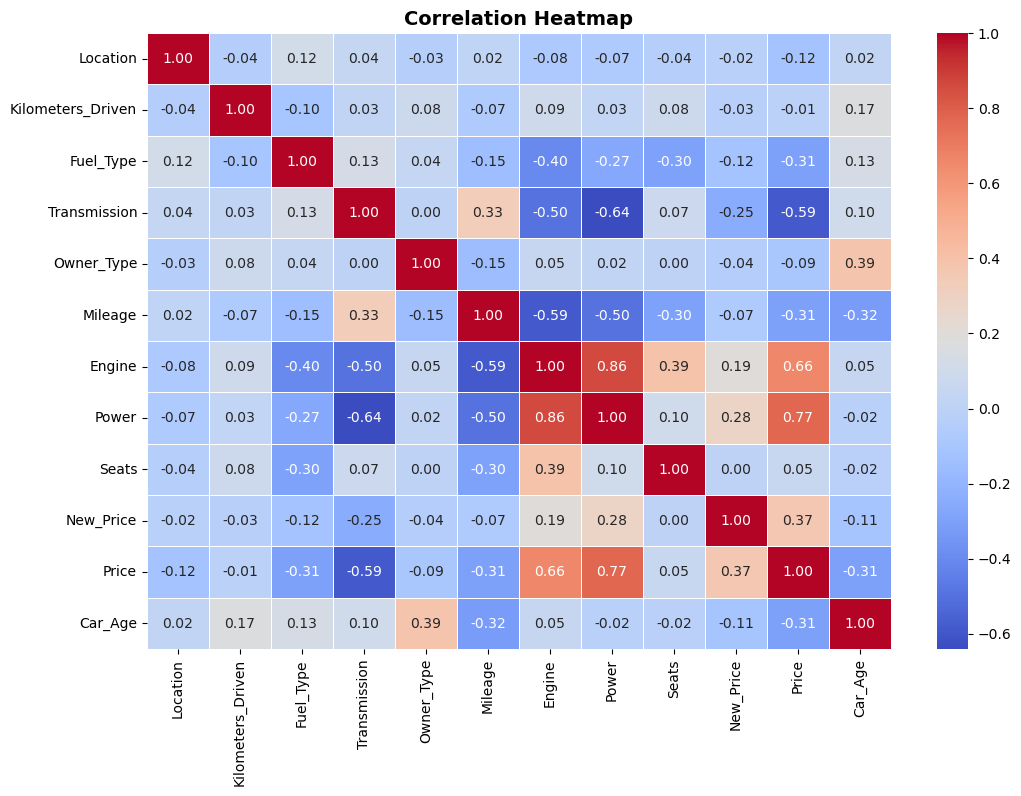

In [18]:
# Correlation Heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Heatmap',
          fontsize=14,
          fontweight='bold')

plt.show()

## STEP 6 : MODEL BUILDING

In [19]:
# Splitting features and target

X = df.drop(columns=['Price'])
y = df['Price']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                     test_size=0.2,
                                                     random_state=42)

print('Training size:', X_train.shape)
print('Testing size :', X_test.shape)

Training size: (4815, 11)
Testing size : (1204, 11)


In [20]:
# Training Random Forest Regressor

model = RandomForestRegressor(n_estimators=100,
                               random_state=42)

model.fit(X_train, y_train)

print('Model Training Done!')

Model Training Done!


## STEP 7 : MODEL EVALUATION

In [21]:
# Predictions

y_pred = model.predict(X_test)

# Evaluation Metrics
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('===== Model Performance =====')
print(f'MAE  : {mae:.2f}')
print(f'MSE  : {mse:.2f}')
print(f'RMSE : {rmse:.2f}')
print(f'R2 Score : {r2:.4f}')

===== Model Performance =====
MAE  : 1.62
MSE  : 17.01
RMSE : 4.12
R2 Score : 0.8618


### 7. Actual vs Predicted Plot

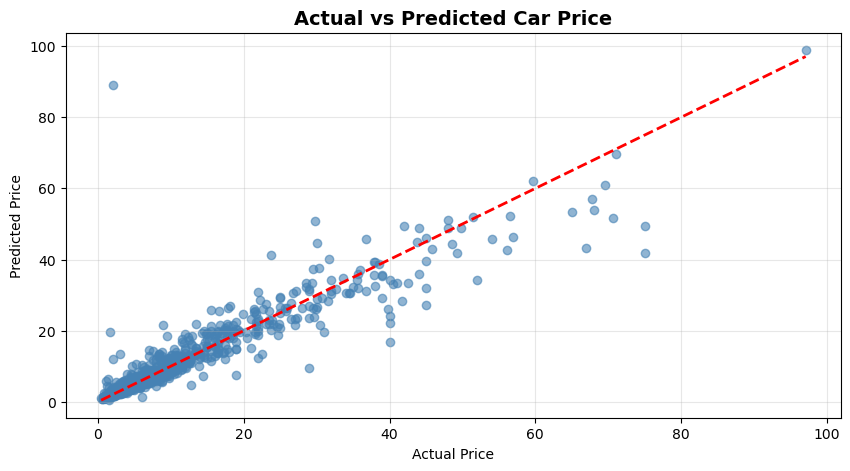

In [22]:
plt.figure(figsize=(10, 5))

plt.scatter(y_test, y_pred,
            color='steelblue',
            alpha=0.6)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2)

plt.title('Actual vs Predicted Car Price',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(alpha=0.3)
plt.show()

### 8. Feature Importance Plot

In [1]:
feat_importance = pd.Series(model.feature_importances_,
                             index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))

feat_importance.plot(kind='bar',
                     color='coral',
                     edgecolor='black')

plt.title('Feature Importance',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'pd' is not defined

## STEP 8 : SAVING THE MODEL

In [24]:
# Saving model with pickle

with open('car_price_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print('Model saved as car_price_model.pkl')

Model saved as car_price_model.pkl


## STEP 9 : KEY INSIGHTS

### Insights from Analysis:

##### 1. Newer cars (less age) generally have higher prices.
##### 2. Automatic transmission cars are priced higher than Manual ones.
##### 3. Engine CC and Power (bhp) have strong positive correlation with Price.
##### 4. CNG cars are generally cheaper compared to Petrol and Diesel.
##### 5. Cars with fewer kilometers driven tend to have higher resale value.
##### 6. Power and Engine size are the most important features for price prediction.

## STEP 10 : FINAL CONCLUSION

#### Conclusion
##### This project built an end-to-end Car Price Prediction system using the used cars dataset.
##### Complete workflow was followed from data loading, cleaning, EDA, model building to deployment.
#### The analysis showed that:
  ##### 1. Random Forest Regressor gives good accuracy for this regression problem.
  ##### 2. Engine power and car age are the strongest predictors of price.
  ##### 3. Proper feature engineering (Car Age, numeric extraction) significantly improved model quality.
##### The trained model is deployed using Streamlit for real-time price prediction.

## END OF PROJECT